This notebook was run on a Colab kernel.

# Setup

---
---

**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Verify Folder structure in drive**

In [2]:
import os
from collections import Counter

def verify_dataset(base_paths):
    print("VERIFYING DATASET STRUCTURE...")
    print("=" * 60)

    total_dataset_size = 0
    total_dataset_files = 0

    for base_path in base_paths:
        if not os.path.exists(base_path):
            print(f"Not found: {base_path} (Skipping)")
            continue

        for root, dirs, files in os.walk(base_path):
            folder_size = sum(os.path.getsize(os.path.join(root, f)) for f in files)
            total_dataset_size += folder_size
            total_dataset_files += len(files)

            ext_counts = Counter(os.path.splitext(f)[1].lower() for f in files)

            level = root.replace(base_path, '').count(os.sep)
            indent = ' ' * 4 * level
            folder_name = os.path.basename(root) if root != base_path else os.path.basename(base_path)

            print(f"{indent} {folder_name}/  [{len(files)} files | {folder_size / (1024*1024):.2f} MB]")

            if files:
                for ext, count in ext_counts.items():
                    ext_name = ext if ext else "no_extension"
                    print(f"{indent}    ├── {count} {ext_name} files")

                examples = sorted(files)
                if len(files) >= 3:
                    examples_str = f"{examples[0]}, {examples[1]}, {examples[2]}, ..."
                else:
                    examples_str = ", ".join(examples)
                print(f"{indent}    └── Examples: {examples_str}\n")
            else:
                print(f"{indent}    └── (Empty folder)\n")

    print("=" * 60)
    print(f"Total Dataset Files: {total_dataset_files}")
    print(f"Total Dataset Size:  {total_dataset_size / (1024*1024):.2f} MB")

paths_to_check = [
    '/content/drive/MyDrive/pheno_crop',
]

verify_dataset(paths_to_check)

# we don't need the sentinel_2_mixed_temp folder .. ignore it for now

VERIFYING DATASET STRUCTURE...
 pheno_crop/  [9 files | 2.55 MB]
    ├── 5 .csv files
    ├── 4 .pth files
    └── Examples: best_model_bilstm.pth, best_model_gru.pth, best_model_lstm.pth, ...

     sentinel_2/  [52 files | 0.95 MB]
        ├── 52 .csv files
        └── Examples: plot_10_indices.csv, plot_11_indices.csv, plot_12_indices.csv, ...

     sentinel_1/  [52 files | 0.17 MB]
        ├── 52 .csv files
        └── Examples: plot_10_sar.csv, plot_11_sar.csv, plot_12_sar.csv, ...

     sentinel_2_mixed_temp/  [239 files | 0.92 MB]
        ├── 227 .tif files
        ├── 12 .csv files
        └── Examples: plot_10_indices.csv, plot_11_indices.csv, plot_12_indices.csv, ...

Total Dataset Files: 352
Total Dataset Size:  4.59 MB


###Setting up the dataset

In [4]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

class ProductionPhenologyDataset(Dataset):
    def __init__(self, gt_path, s1_dir, s2_dir, plot_ids, lookback_days=90, max_seq_len=30):
        self.lookback_days = lookback_days
        self.max_seq_len = max_seq_len

        self.gt = pd.read_csv(gt_path)
        self.gt['date'] = pd.to_datetime(self.gt['date'])
        self.gt = self.gt[self.gt['plot_id'].isin(plot_ids)].reset_index(drop=True)

        self.s1_data, self.s2_data = {}, {}

        print("Loading CSVs into memory...")
        for pid in plot_ids:
            s1_path = os.path.join(s1_dir, f"plot_{pid}_sar.csv")
            if os.path.exists(s1_path):
                df1 = pd.read_csv(s1_path)
                df1['date'] = pd.to_datetime(df1['date'])
                self.s1_data[pid] = df1

            s2_path = os.path.join(s2_dir, f"plot_{pid}_indices.csv")
            if os.path.exists(s2_path):
                df2 = pd.read_csv(s2_path)
                df2['date'] = pd.to_datetime(df2['date'])
                self.s2_data[pid] = df2
        print(f"Dataset ready. Found {len(self.gt)} ground truth events.")

    def __len__(self): return len(self.gt)

    def __getitem__(self, idx):
        row = self.gt.iloc[idx]
        target_date, plot_id, label = row['date'], row['plot_id'], row['stage_code']
        start_date = target_date - pd.Timedelta(days=self.lookback_days)

        s1_df = self.s1_data.get(plot_id, pd.DataFrame())
        s1_tensor = torch.zeros((self.max_seq_len, 3), dtype=torch.float32)
        s1_days_tensor = torch.zeros((self.max_seq_len,), dtype=torch.float32)

        if not s1_df.empty:
            mask = (s1_df['date'] > start_date) & (s1_df['date'] <= target_date)
            valid_s1 = s1_df[mask]
            if len(valid_s1) > 0:
                features = valid_s1[['VV', 'VH', 'VH_VV_Ratio']].values
                days_ago = (target_date - valid_s1['date']).dt.days.values
                seq_len = min(len(features), self.max_seq_len)
                s1_tensor[-seq_len:] = torch.tensor(features[-seq_len:], dtype=torch.float32)
                s1_days_tensor[-seq_len:] = torch.tensor(days_ago[-seq_len:], dtype=torch.float32)

        s2_df = self.s2_data.get(plot_id, pd.DataFrame())
        s2_tensor = torch.zeros((self.max_seq_len, 9), dtype=torch.float32)
        s2_days_tensor = torch.zeros((self.max_seq_len,), dtype=torch.float32)

        if not s2_df.empty:
            mask = (s2_df['date'] > start_date) & (s2_df['date'] <= target_date)
            valid_s2 = s2_df[mask]
            if len(valid_s2) > 0:
                features = valid_s2[['NDVI', 'NDWI', 'NDRE', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'GNDVI', 'cloud_pct']].values
                days_ago = (target_date - valid_s2['date']).dt.days.values
                seq_len = min(len(features), self.max_seq_len)
                s2_tensor[-seq_len:] = torch.tensor(features[-seq_len:], dtype=torch.float32)
                s2_days_tensor[-seq_len:] = torch.tensor(days_ago[-seq_len:], dtype=torch.float32)

        return {
            's1_feats': s1_tensor, 's1_days': s1_days_tensor,
            's2_feats': s2_tensor, 's2_days': s2_days_tensor,
            'label': torch.tensor(label, dtype=torch.long)
        }

---
---

## Model 1: Dual-Stream Hybrid Crop Phenology Network
**Architecture Blueprint**

This model is a late-fusion, multimodal neural network designed to predict winter wheat growth stages (Stages 0-4) using asynchronous, cloud-obstructed satellite imagery. It processes two independent data streams: Sentinel-2 (Optical) and Sentinel-1 (Radar); before fusing their latent representations into a final predictive multi-layer perceptron (MLP).

### Phase 1: The Asynchronous Data Pipeline (Alignment)
Standard neural networks require periodic, rigid time series. Satellite flyovers are highly irregular, and optical data is frequently corrupted by clouds. The dataset class acts as the alignment engine to solve this.

* **The Anchor Point:** The exact date the ground truth observation was made is set as `Day 0`. The dataset looks backward 90 days.
* **Sequence Padding:**  The pipeline extracts a maximum of 30 satellite flyovers within that window. If a field has fewer than 30 flyovers, the remaining slots are padded with zeros.
* **The Time Tensor:** For every reading, the pipeline calculates the exact `days_ago` integer.
* **The Outputs:** For each field, the dataloader produces four parallel tensors:
  * Optical: `s2_feats` shape $30 \times 9$, `s2_days` shape $30$
  * Radar: `s1_feats` shape $30 \times 3$, `s1_days` shape $30$

---

### Phase 2A: The Sentinel-2 (Optical) Pipeline
**Design:** CNN + Transformer Encoder Hybrid

**Purpose:** To extract the biological growth curve while dynamically filtering out cloudy/corrupted days.

1. **Local Micro-Trend Extraction (1D CNN):** The $30 \times 9$ optical tensor passes through a 1D Convolutional Neural Network with a 3-day sliding window. This smooths out sensor noise and calculates local gradients (e.g., a sharp 3-day drop in moisture), projecting the features into a richer $64$-D space.
2. **Positional Time Embedding:** The integer `s2_days` tensor is passed through an `nn.Embedding(120, 64)`. This creates a $64$-D mathematical signature representing *exactly when* the reading occurred. This is added to the CNN output, ensuring the network understands the massive irregular gaps between clear days.
3. **The `[CLS]` Token Injection:**  A blank, learnable $64$-D vector (the Classification Token) is prepended to the 30-day sequence, expanding the sequence length to 31. This token acts as a sponge.
4. **Global Reasoning (Transformer Stack):** The 31-step sequence enters a stack of Transformer Encoder blocks. The Multi-Head Attention mechanism looks at the entire 90-day timeline simultaneously. It mathematically mutes days with high `cloud_pct` and maps the long-term relationships of the vegetation indices.
5. **Output Slice:** The network discards the 30 real days and outputs only the heavily refined `[CLS]` token, yielding a single $64$-D summary vector of the optical history.

---

### Phase 2B: The Sentinel-1 (Radar) Pipeline
**Design:** CNN + GRU Hybrid

**Purpose:** To track the continuous physical structure and volume scattering of the crop canopy.

1. **Noise Reduction & Shape Detection (1D CNN):** Radar data is inherently noisy (speckle). The $30 \times 3$ radar tensor passes through a 1D CNN. The sliding window smooths the speckle and identifies short-term structural shapes (like the steep drop in VH backscatter right before harvest). It projects the 3 features into a $64$-D space.
2. **Positional Time Embedding:** Just like the optical stream, the `s1_days` integers are embedded and added to the CNN features, anchoring the structural shapes to their exact place in the 90-day window.
3. **Long-Term Structural Memory (GRU):**  Because radar effortlessly punches through clouds, the timeline is highly continuous. The time-stamped CNN features are fed sequentially into a Gated Recurrent Unit (GRU). The GRU steps through the days, smoothly updating its internal "memory" of how tall and dense the wheat stalks are getting.
4. **Output State:** The network extracts the final hidden state of the GRU, yielding a single $64$-D summary vector of the field's structural history.

---

### Phase 3: The Late Fusion Layer

Up until this point, the two pipelines have operated completely independently. The Fusion Layer bridges the physics and the chemistry.
* The $64$-D Optical summary and the $64$-D Radar summary are concatenated into a single $128$-D vector.

### Phase 4: The Multi-Layer Perceptron (Classifier)
The fused $128$-D vector is passed through a dense Feed-Forward network.
* **Architecture:** `Linear(128, 64) -> BatchNorm1d -> ReLU -> Dropout(0.4) -> Linear(64, 5)`
* **Dropout & BatchNorm:** Included to prevent the model from overfitting to the training plots, forcing it to learn robust, generalized rules.
* **Output:** The final Linear layer outputs 5 raw logits representing the probabilities for Stage 0, Stage 1, Stage 2, Stage 3, and Stage 4.

#### Model Setup

In [5]:
class OpticalBranch(nn.Module):
    def __init__(self, in_features=9, embed_dim=64, num_layers=2):
        super().__init__()
        self.local_cnn = nn.Sequential(
            nn.Conv1d(in_channels=in_features, out_channels=embed_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=embed_dim, out_channels=embed_dim, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.time_embed = nn.Embedding(120, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=128, dropout=0.3, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x, days_ago):
        batch_size = x.size(0)
        x = x.transpose(1, 2)
        cnn_out = self.local_cnn(x).transpose(1, 2)

        days_clamped = torch.clamp(days_ago.long(), 0, 119)
        feats_with_time = cnn_out + self.time_embed(days_clamped)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        transformer_in = torch.cat((cls_tokens, feats_with_time), dim=1)
        transformer_out = self.transformer(transformer_in)

        return transformer_out[:, 0, :]

class RadarBranch(nn.Module):
    def __init__(self, in_features=3, embed_dim=64):
        super().__init__()
        self.local_cnn = nn.Sequential(
            nn.Conv1d(in_channels=in_features, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=embed_dim, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.time_embed = nn.Embedding(120, embed_dim)
        self.gru = nn.GRU(input_size=embed_dim, hidden_size=embed_dim, num_layers=2, batch_first=True, dropout=0.2)

    def forward(self, x, days_ago):
        x = x.transpose(1, 2)
        cnn_out = self.local_cnn(x).transpose(1, 2)

        days_clamped = torch.clamp(days_ago.long(), 0, 119)
        feats_with_time = cnn_out + self.time_embed(days_clamped)

        _, h_n = self.gru(feats_with_time)

        return h_n[-1]

class MasterPhenologyNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.optical_branch = OpticalBranch(in_features=9, embed_dim=64)
        self.radar_branch = RadarBranch(in_features=3, embed_dim=64)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, s1_feats, s1_days, s2_feats, s2_days):
        radar_summary = self.radar_branch(s1_feats, s1_days)
        optical_summary = self.optical_branch(s2_feats, s2_days)

        fused = torch.cat([radar_summary, optical_summary], dim=1)
        return self.classifier(fused)

define model save path

In [6]:
save_path = '/content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth'

#### Training

In [7]:
def train_model(dataset, epochs=50, batch_size=32, lr=0.001):

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    print("Calculating dynamic class weights...")
    train_labels = [train_ds[i]['label'].item() for i in range(len(train_ds))]
    class_counts = torch.bincount(torch.tensor(train_labels), minlength=5)
    class_counts = torch.where(class_counts == 0, torch.tensor(1), class_counts)
    class_weights = len(train_labels) / (5.0 * class_counts.float())

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on {device} | {train_size} Train events | {val_size} Val events")

    model = MasterPhenologyNet(num_classes=5).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for batch in train_loader:
            s1_f, s1_d = batch['s1_feats'].to(device), batch['s1_days'].to(device)
            s2_f, s2_d = batch['s2_feats'].to(device), batch['s2_days'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            logits = model(s1_f, s1_d, s2_f, s2_d)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            _, preds = torch.max(logits, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                s1_f, s1_d = batch['s1_feats'].to(device), batch['s1_days'].to(device)
                s2_f, s2_d = batch['s2_feats'].to(device), batch['s2_days'].to(device)
                labels = batch['label'].to(device)

                logits = model(s1_f, s1_d, s2_f, s2_d)
                loss = criterion(logits, labels)

                val_loss += loss.item() * labels.size(0)
                _, preds = torch.max(logits, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            t_acc = (train_correct / train_total) * 100
            v_acc = (val_correct / val_total) * 100
            v_loss = val_loss / val_total if val_total else float('inf')
            print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Acc: {t_acc:.1f}% | Val Acc: {v_acc:.1f}% | Val Loss: {v_loss:.4f}")

        v_loss = val_loss / val_total if val_total else float('inf')
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            save_path = '/content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth'
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
            }, save_path)
            print(f"Epoch: {epoch+1:02d} (Val Loss dropped to {v_loss:.4f}). Saved to {save_path}")

    return model

In [8]:
gt_path = '/content/drive/MyDrive/pheno_crop/ground_truth.csv'
s1_dir = '/content/drive/MyDrive/pheno_crop/sentinel_1'
s2_dir = '/content/drive/MyDrive/pheno_crop/sentinel_2'

all_plots = list(range(2, 54))

full_dataset = ProductionPhenologyDataset(gt_path, s1_dir, s2_dir, plot_ids=all_plots)

final_model = train_model(full_dataset, epochs=100, batch_size=32)

Loading CSVs into memory...
Dataset ready. Found 1428 ground truth events.
Calculating dynamic class weights...
Training on cpu | 1142 Train events | 286 Val events
Epoch [01/100] | Train Acc: 42.0% | Val Acc: 75.2% | Val Loss: 0.9239
Epoch: 01 (Val Loss dropped to 0.9239). Saved to /content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth
Epoch: 02 (Val Loss dropped to 0.7519). Saved to /content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth
Epoch: 03 (Val Loss dropped to 0.6010). Saved to /content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth
Epoch [05/100] | Train Acc: 74.2% | Val Acc: 75.2% | Val Loss: 0.5891
Epoch: 05 (Val Loss dropped to 0.5891). Saved to /content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth
Epoch: 06 (Val Loss dropped to 0.5851). Saved to /content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth
Epoch: 07 (Val Loss dropped to 0.5776). Saved to /content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth
Epoch: 09 (Val Lo

**Verify the model exists**

In [9]:
from google.colab import files
import os
print(os.path.exists('/content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth'))
print(os.stat('/content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth').st_size)

True
2003227


**Testing on a Sample**

In [10]:
import torch
import torch.nn.functional as F

checkpoint = torch.load(save_path, map_location=torch.device('cpu'))
inference_model = MasterPhenologyNet(num_classes=5)
inference_model.load_state_dict(checkpoint['model_state_dict'])

inference_model.eval()

sample_idx = 7
sample = full_dataset[sample_idx]
actual_label = sample['label'].item()
plot_id = full_dataset.gt.iloc[sample_idx]['plot_id']

s1_f = sample['s1_feats'].unsqueeze(0)
s1_d = sample['s1_days'].unsqueeze(0)
s2_f = sample['s2_feats'].unsqueeze(0)
s2_d = sample['s2_days'].unsqueeze(0)

with torch.no_grad():
    raw_logits = inference_model(s1_f, s1_d, s2_f, s2_d)
    probabilities = F.softmax(raw_logits, dim=1).squeeze()
    predicted_class = torch.argmax(probabilities).item()

print(f"Testing Plot ID: {plot_id}")
print("-" * 30)
print(f"Ground Truth : Stage {actual_label}")
print(f"Prediction: Stage {predicted_class}")
print("-" * 30)
print("Confidence Breakdown:")

for stage, prob in enumerate(probabilities):
    marker = "(Prediction)" if stage == predicted_class else ""
    print(f"Stage {stage}: {prob * 100:>5.1f}% {marker}")

Testing Plot ID: 2
------------------------------
Ground Truth : Stage 2
Prediction: Stage 2
------------------------------
Confidence Breakdown:
Stage 0:   0.0% 
Stage 1:   0.3% 
Stage 2:  80.2% (Prediction)
Stage 3:  19.6% 
Stage 4:   0.0% 


**Running full testing**

In [11]:
import torch
import torch.nn.functional as F
import pandas as pd

model_path = '/content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth'
checkpoint = torch.load(save_path, map_location=torch.device('cpu'))
inference_model = MasterPhenologyNet(num_classes=5)
inference_model.load_state_dict(checkpoint['model_state_dict'])
inference_model.eval()

print(f"Starting mass inference on {len(full_dataset)} events...")
all_predictions = []

with torch.no_grad():
    for i in range(len(full_dataset)):

        sample = full_dataset[i]

        plot_id = full_dataset.gt.iloc[i]['plot_id']
        date = full_dataset.gt.iloc[i]['date']
        actual_label = sample['label'].item()

        s1_f = sample['s1_feats'].unsqueeze(0)
        s1_d = sample['s1_days'].unsqueeze(0)
        s2_f = sample['s2_feats'].unsqueeze(0)
        s2_d = sample['s2_days'].unsqueeze(0)

        raw_logits = inference_model(s1_f, s1_d, s2_f, s2_d)
        probabilities = F.softmax(raw_logits, dim=1).squeeze()
        predicted_class = torch.argmax(probabilities).item()

        all_predictions.append({
            'plot_id': plot_id,
            'date': date.strftime('%Y-%m-%d'),
            'actual_stage': actual_label,
            'predicted_stage': predicted_class,
            'correct_prediction': bool(actual_label == predicted_class),
            'prob_stage_0': round(probabilities[0].item() * 100, 2),
            'prob_stage_1': round(probabilities[1].item() * 100, 2),
            'prob_stage_2': round(probabilities[2].item() * 100, 2),
            'prob_stage_3': round(probabilities[3].item() * 100, 2),
            'prob_stage_4': round(probabilities[4].item() * 100, 2)
        })

        if (i + 1) % 200 == 0:
            print(f"   Processed {i + 1} / {len(full_dataset)} events...")

output_csv_path = '/content/drive/MyDrive/pheno_crop/predictions_output.csv'
results_df = pd.DataFrame(all_predictions)
results_df.to_csv(output_csv_path, index=False)

total_correct = results_df['correct_prediction'].sum()
total_accuracy = (total_correct / len(results_df)) * 100

print("-" * 40)
print(f"Inference Complete!")
print(f"Total Dataset Accuracy: {total_accuracy:.2f}%")
print(f"CSV saved to: {output_csv_path}")
print("-" * 40)

Starting mass inference on 1428 events...
   Processed 200 / 1428 events...
   Processed 400 / 1428 events...
   Processed 600 / 1428 events...
   Processed 800 / 1428 events...
   Processed 1000 / 1428 events...
   Processed 1200 / 1428 events...
   Processed 1400 / 1428 events...
----------------------------------------
Inference Complete!
Total Dataset Accuracy: 83.96%
CSV saved to: /content/drive/MyDrive/pheno_crop/predictions_output.csv
----------------------------------------


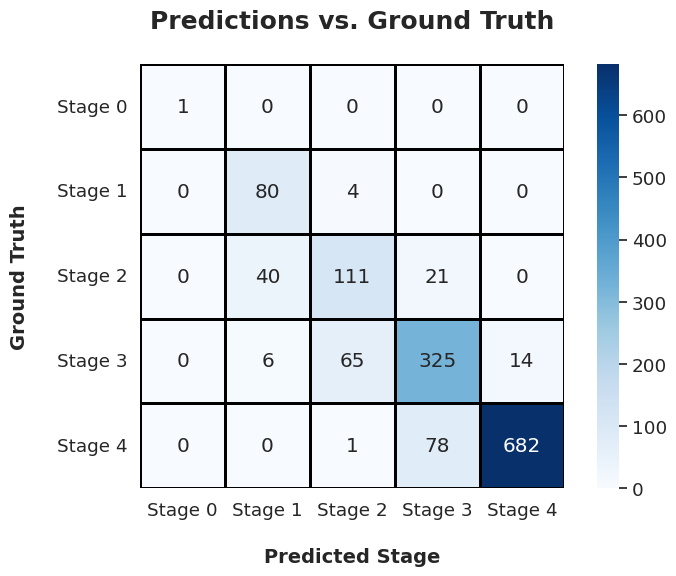

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

csv_path = '/content/drive/MyDrive/pheno_crop/predictions_output.csv'
df = pd.read_csv(csv_path)

y_true = df['actual_stage']
y_pred = df['predicted_stage']

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
sns.set_theme(style="white", font_scale=1.2)

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    square=True,
    linewidths=1,
    linecolor='black'
)

ax.set_title('Predictions vs. Ground Truth\n', fontsize=18, fontweight='bold')
ax.set_xlabel('\nPredicted Stage', fontsize=14, fontweight='bold')
ax.set_ylabel('Ground Truth\n', fontsize=14, fontweight='bold')

stage_names = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
ax.set_xticklabels(stage_names)
ax.set_yticklabels(stage_names, rotation=0)

plt.tight_layout()
plt.show()

Extracting 128-D vectors from the Fusion Layer...
Squashing 128 dimensions down to 2D...


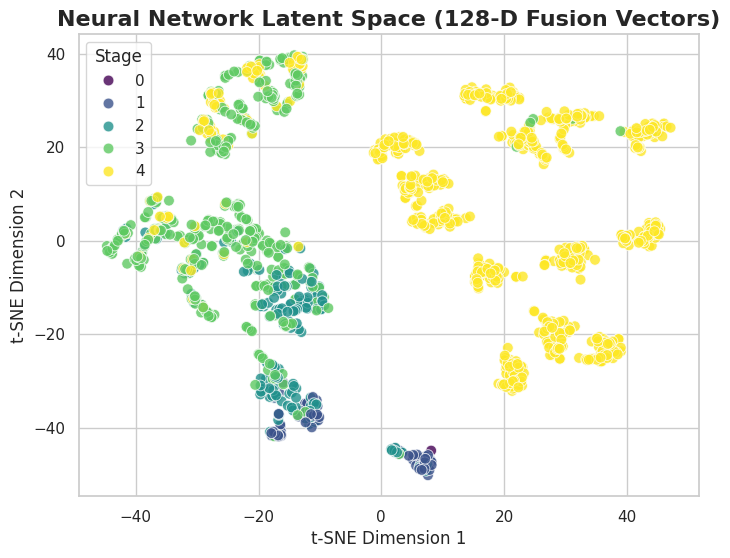

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

model_path = '/content/drive/MyDrive/pheno_crop/curr_best_phenology_model.pth'
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
model = MasterPhenologyNet(num_classes=5)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

embeddings = []
labels = []

def get_activation():
    def hook(module, input):
        embeddings.append(input[0].detach().cpu().numpy())
    return hook

hook_handle = model.classifier[0].register_forward_pre_hook(get_activation())

print("Extracting 128-D vectors from the Fusion Layer...")
with torch.no_grad():
    for i in range(len(full_dataset)):
        sample = full_dataset[i]
        s1_f = sample['s1_feats'].unsqueeze(0)
        s1_d = sample['s1_days'].unsqueeze(0)
        s2_f = sample['s2_feats'].unsqueeze(0)
        s2_d = sample['s2_days'].unsqueeze(0)

        _ = model(s1_f, s1_d, s2_f, s2_d)
        labels.append(sample['label'].item())

hook_handle.remove()

print("Squashing 128 dimensions down to 2D...")
embeddings_array = np.concatenate(embeddings, axis=0)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_array)

df_tsne = pd.DataFrame({
    'X': embeddings_2d[:, 0],
    'Y': embeddings_2d[:, 1],
    'Stage': labels
})

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x='X', y='Y',
    hue='Stage',
    palette='viridis',
    data=df_tsne,
    legend='full',
    alpha=0.8,
    s=60
)

plt.title("Neural Network Latent Space (128-D Fusion Vectors)", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

# **2**. Baseline Temporal Sequence Models (LSTM / GRU / BiLSTM)

###Architecture Blueprint

These models serve as baseline sequence learners to benchmark the performance of the advanced dual-stream fusion network. Unlike the hybrid model, they treat the multimodal satellite data as a single fused time-series, without explicitly modeling modality-specific dynamics.

The goal is to evaluate how well standard recurrent architectures can learn crop growth patterns without specialized fusion mechanisms.


#Phase 1: Unified Time-Series Construction

Purpose:
To convert heterogeneous Sentinel-1 (Radar) and Sentinel-2 (Optical) signals into a single sequential representation.

Feature Fusion (Early Fusion Strategy):
Radar features: 3 channels → (VV, VH, VH/VV)
Optical features: 9 channels → (NDVI, NDWI, NDRE, EVI, SAVI, MSAVI, NDMI, GNDVI, cloud_pct)

These are concatenated at each timestep:

Input Tensor Shape: 30 × 12


Temporal Windowing:
Anchor: Ground truth observation date (Day 0)
Lookback window: 90 days
Maximum sequence length: 30 timesteps


Padding Strategy:
If fewer than 30 observations:
Remaining timesteps are zero-padded

No masking is used → model must implicitly learn padding


#Phase 2: Temporal Modeling

The fused sequence is processed using different recurrent architectures:


##A. Long Short-Term Memory (LSTM)

Design:
Standard unidirectional LSTM

Purpose:
To capture long-term temporal dependencies in vegetation growth patterns.

Mechanism:
Processes sequence step-by-step
Maintains hidden state (short-term memory)
Maintains cell state (long-term memory)

Output Extraction:
Only the final hidden state is used

Output Vector: 64-D

Represents compressed crop growth history


##B. Gated Recurrent Unit (GRU)

Design:
Simplified recurrent model with fewer parameters

Purpose:
To provide a faster, lightweight alternative to LSTM

Mechanism:
Uses update gate and reset gate
No separate cell state → more efficient

Output Extraction:
Final hidden state → 64-D vector


##C. Bidirectional LSTM (BiLSTM)

Design:
Processes sequence in both forward and backward directions

Purpose:
To capture:
- Early-stage signals influencing later stages
- Late-stage signals contextualizing earlier patterns

Mechanism:
Forward LSTM → learns past → future
Backward LSTM → learns future → past

Output Extraction:
Final forward + backward states are concatenated

Output Vector: 128-D


#Phase 3: Classification Head

Each model uses a simple fully connected classifier.


LSTM / GRU:
Linear(64 → 5)


BiLSTM:
Linear(128 → 5)


Output:
The final layer outputs 5 logits representing:
Stage 0, Stage 1, Stage 2, Stage 3, Stage 4


#Key Limitations of Baseline Models

No modality separation:
Radar and Optical signals are treated equally without physics-aware modeling.

No temporal irregularity handling:
No explicit time embedding is used; assumes uniform sampling.

No noise filtering:
No CNN-based smoothing; sensitive to cloud-corrupted optical data.

No attention mechanism:
Cannot dynamically focus on important timesteps.


#Expected Behavior

LSTM:
Strong temporal memory but computationally heavier.

GRU:
Faster and more efficient but slightly less expressive.

BiLSTM:
Captures richer temporal context but increases computation.


#Role in the Project

These models act as:
- Control group (baseline)
- Performance benchmark
- Ablation reference


#Key Insight

If the dual-stream fusion model significantly outperforms these baselines, it demonstrates that:
- Modality-aware learning is important
- Temporal alignment is critical
- Attention mechanisms improve performance

In [14]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(12, 64, batch_first=True)
        self.fc = nn.Linear(64, 5)

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=2)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(12, 64, batch_first=True)
        self.fc = nn.Linear(64, 5)

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=2)
        _, h = self.gru(x)
        return self.fc(h[-1])

class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(12, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 5)

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=2)
        _, (h, _) = self.lstm(x)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(h_cat)

###Training

In [15]:
def train_model(dataset, model, model_name, epochs=50, batch_size=32, lr=0.001):

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_acc = 0.0
    save_path = f'/content/drive/MyDrive/pheno_crop/best_model_{model_name}.pth'

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            s1 = batch['s1_feats'].to(device)
            s2 = batch['s2_feats'].to(device)
            y = batch['label'].to(device)

            optimizer.zero_grad()
            out = model(s1, s2)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                s1 = batch['s1_feats'].to(device)
                s2 = batch['s2_feats'].to(device)
                y = batch['label'].to(device)

                out = model(s1, s2)
                preds = torch.argmax(out, dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        acc = 100 * correct / total
        print(f"[{model_name}] Epoch {epoch+1}: Val Acc = {acc:.2f}%")

        # save best model
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)
            print(f"🔥 Saved {model_name} at epoch {epoch+1} | Acc: {acc:.2f}%")

    return model

In [16]:
lstm_model = train_model(full_dataset, LSTMModel(),model_name="lstm", epochs=50)
gru_model = train_model(full_dataset, GRUModel(),model_name="gru", epochs=50)
bilstm_model = train_model(full_dataset, BiLSTMModel(),model_name="bilstm", epochs=50)

[lstm] Epoch 1: Val Acc = 52.45%
🔥 Saved lstm at epoch 1 | Acc: 52.45%
[lstm] Epoch 2: Val Acc = 70.63%
🔥 Saved lstm at epoch 2 | Acc: 70.63%
[lstm] Epoch 3: Val Acc = 76.57%
🔥 Saved lstm at epoch 3 | Acc: 76.57%
[lstm] Epoch 4: Val Acc = 77.62%
🔥 Saved lstm at epoch 4 | Acc: 77.62%
[lstm] Epoch 5: Val Acc = 78.67%
🔥 Saved lstm at epoch 5 | Acc: 78.67%
[lstm] Epoch 6: Val Acc = 78.67%
[lstm] Epoch 7: Val Acc = 78.67%
[lstm] Epoch 8: Val Acc = 80.07%
🔥 Saved lstm at epoch 8 | Acc: 80.07%
[lstm] Epoch 9: Val Acc = 79.72%
[lstm] Epoch 10: Val Acc = 78.32%
[lstm] Epoch 11: Val Acc = 80.42%
🔥 Saved lstm at epoch 11 | Acc: 80.42%
[lstm] Epoch 12: Val Acc = 81.12%
🔥 Saved lstm at epoch 12 | Acc: 81.12%
[lstm] Epoch 13: Val Acc = 81.82%
🔥 Saved lstm at epoch 13 | Acc: 81.82%
[lstm] Epoch 14: Val Acc = 81.12%
[lstm] Epoch 15: Val Acc = 81.47%
[lstm] Epoch 16: Val Acc = 82.87%
🔥 Saved lstm at epoch 16 | Acc: 82.87%
[lstm] Epoch 17: Val Acc = 82.17%
[lstm] Epoch 18: Val Acc = 82.87%
[lstm] Epoch 

**Verify the model exists**

In [17]:
import os

base = '/content/drive/MyDrive/pheno_crop'

print(os.path.exists(f"{base}/best_model_lstm.pth"))
print(os.path.exists(f"{base}/best_model_gru.pth"))
print(os.path.exists(f"{base}/best_model_bilstm.pth"))

True
True
True


**Testing on a Sample**

In [18]:
import torch
import torch.nn.functional as F

# 🔹 Load model
model_path = '/content/drive/MyDrive/pheno_crop/best_model_bilstm.pth'

model = BiLSTMModel()
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

# 🔹 Get sample
sample_idx = 7
sample = full_dataset[sample_idx]

actual_label = sample['label'].item()
plot_id = full_dataset.gt.iloc[sample_idx]['plot_id']

s1 = sample['s1_feats'].unsqueeze(0)
s2 = sample['s2_feats'].unsqueeze(0)

# 🔹 Inference
with torch.no_grad():
    logits = model(s1, s2)
    probs = F.softmax(logits, dim=1).squeeze()
    pred = torch.argmax(probs).item()

# 🔹 Output
print(f"Testing Plot ID: {plot_id}")
print("-" * 30)
print(f"Ground Truth : Stage {actual_label}")
print(f"Prediction   : Stage {pred}")
print("-" * 30)
print("Confidence Breakdown:")

for i, p in enumerate(probs):
    mark = "(Prediction)" if i == pred else ""
    print(f"Stage {i}: {p.item()*100:.1f}% {mark}")

Testing Plot ID: 2
------------------------------
Ground Truth : Stage 2
Prediction   : Stage 2
------------------------------
Confidence Breakdown:
Stage 0: 0.1% 
Stage 1: 3.1% 
Stage 2: 53.3% (Prediction)
Stage 3: 43.3% 
Stage 4: 0.2% 


**Running Full Testing**

In [19]:
import torch
import torch.nn.functional as F
import pandas as pd

# ✅ Choose model
model_path = '/content/drive/MyDrive/pheno_crop/best_model_bilstm.pth'

model = BiLSTMModel()
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

print(f"Starting mass inference on {len(full_dataset)} events...")

all_predictions = []

with torch.no_grad():
    for i in range(len(full_dataset)):

        sample = full_dataset[i]

        plot_id = full_dataset.gt.iloc[i]['plot_id']
        date = full_dataset.gt.iloc[i]['date']
        actual_label = sample['label'].item()

        s1 = sample['s1_feats'].unsqueeze(0)
        s2 = sample['s2_feats'].unsqueeze(0)

        logits = model(s1, s2)
        probs = F.softmax(logits, dim=1).squeeze()
        pred = torch.argmax(probs).item()

        all_predictions.append({
            'plot_id': plot_id,
            'date': date.strftime('%Y-%m-%d'),
            'actual_stage': actual_label,
            'predicted_stage': pred,
            'correct_prediction': actual_label == pred,
            'prob_stage_0': round(probs[0].item() * 100, 2),
            'prob_stage_1': round(probs[1].item() * 100, 2),
            'prob_stage_2': round(probs[2].item() * 100, 2),
            'prob_stage_3': round(probs[3].item() * 100, 2),
            'prob_stage_4': round(probs[4].item() * 100, 2)
        })

        if (i + 1) % 200 == 0:
            print(f"Processed {i+1}/{len(full_dataset)}")

# Save results
output_csv_path = '/content/drive/MyDrive/pheno_crop/predictions_bilstm.csv'
results_df = pd.DataFrame(all_predictions)
results_df.to_csv(output_csv_path, index=False)

# Accuracy
accuracy = results_df['correct_prediction'].mean() * 100

print("-" * 40)
print(f"LSTM Accuracy: {accuracy:.2f}%")
print(f"Saved to: {output_csv_path}")
print("-" * 40)

Starting mass inference on 1428 events...
Processed 200/1428
Processed 400/1428
Processed 600/1428
Processed 800/1428
Processed 1000/1428
Processed 1200/1428
Processed 1400/1428
----------------------------------------
LSTM Accuracy: 84.87%
Saved to: /content/drive/MyDrive/pheno_crop/predictions_bilstm.csv
----------------------------------------


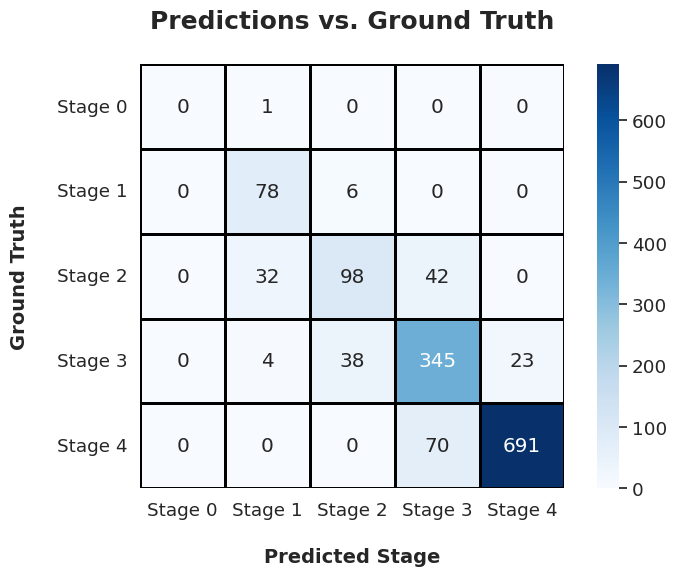

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

csv_path = '/content/drive/MyDrive/pheno_crop/predictions_bilstm.csv'
df = pd.read_csv(csv_path)

y_true = df['actual_stage']
y_pred = df['predicted_stage']

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(8, 6))
sns.set_theme(style="white", font_scale=1.2)

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    square=True,
    linewidths=1,
    linecolor='black'
)

ax.set_title('Predictions vs. Ground Truth\n', fontsize=18, fontweight='bold')
ax.set_xlabel('\nPredicted Stage', fontsize=14, fontweight='bold')
ax.set_ylabel('Ground Truth\n', fontsize=14, fontweight='bold')

stage_names = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
ax.set_xticklabels(stage_names)
ax.set_yticklabels(stage_names, rotation=0)

plt.tight_layout()
plt.show()

Extracting embeddings from LSTM...
Running t-SNE...


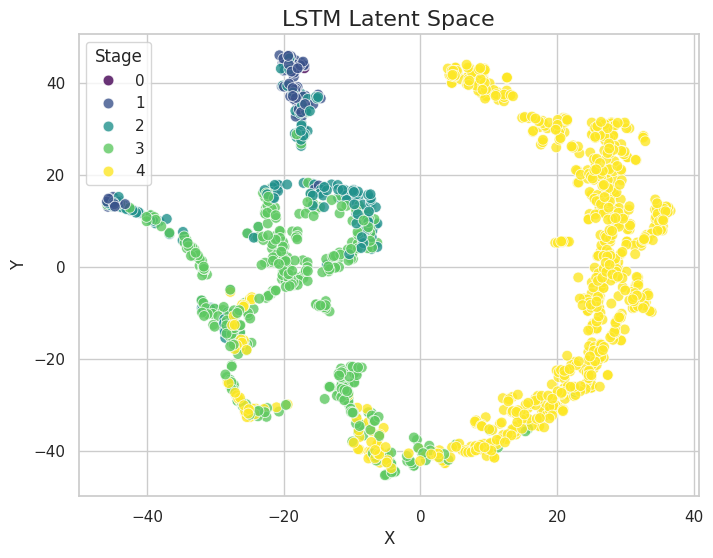

In [21]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Load model
model_path = '/content/drive/MyDrive/pheno_crop/best_model_lstm.pth'
model = LSTMModel()
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

embeddings = []
labels = []

print("Extracting embeddings from LSTM...")

with torch.no_grad():
    for i in range(len(full_dataset)):
        sample = full_dataset[i]

        s1 = sample['s1_feats'].unsqueeze(0)
        s2 = sample['s2_feats'].unsqueeze(0)

        x = torch.cat([s1, s2], dim=2)

        # 🔥 get hidden state manually
        _, (h, _) = model.lstm(x)
        embedding = h[-1].squeeze().numpy()

        embeddings.append(embedding)
        labels.append(sample['label'].item())

# Convert
embeddings_array = np.array(embeddings)

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_array)

# DataFrame
df_tsne = pd.DataFrame({
    'X': embeddings_2d[:, 0],
    'Y': embeddings_2d[:, 1],
    'Stage': labels
})

# Plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x='X', y='Y',
    hue='Stage',
    palette='viridis',
    data=df_tsne,
    alpha=0.8,
    s=60
)

plt.title("LSTM Latent Space", fontsize=16)
plt.show()